In [41]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Priyanshu Kumar\Desktop\Student Burnout & Acedemic Risk Prediction System\data\raw\student_burnout_dataset_350.csv")

In [42]:
df["academic_risk"] = pd.cut(df["cgpa"], bins=[0,6,8,10], labels=["High","Medium","Low"])
df["academic_risk"].value_counts()

academic_risk
Medium    152
Low       125
High       73
Name: count, dtype: int64

In [43]:
X = df.drop(["cgpa","academic_risk","burnout_score","burnout_level","student_id"], axis=1)
y = df["academic_risk"]
X.head()

,age,gender,study_hours_per_day,sleep_hours_per_day,attendance_percentage,assignment_delay_days,screen_time_hours,physical_activity_hours
0,24,Female,5.7,8.8,63.4,5,6.2,1.4
1,21,Male,4.0,8.1,89.9,7,3.6,0.9
2,22,Male,2.5,8.4,65.5,1,6.9,1.4
3,24,Female,4.7,5.9,72.8,2,4.4,1.8
4,20,Female,4.3,5.3,50.6,5,5.4,1.5


In [44]:
X = pd.get_dummies(X, drop_first=True)
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [47]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score


results = []

for name, model in models.items():
    
    if name in ["Logistic Regression", "SVM", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })


In [48]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Macro F1", ascending=False)

results_df

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.442857,0.340696,0.389228
4,Naive Bayes,0.414286,0.323679,0.371474
1,Random Forest,0.371429,0.279345,0.329601
3,KNN,0.300000,0.254614,0.281942
2,SVM,0.328571,0.230416,0.277616


The Academic Risk classifier achieved moderate performance (Accuracy ≈ 44%, Macro F1 ≈ 0.34).
This suggests that lifestyle features such as study hours, sleep patterns, attendance, and screen time have limited predictive power for academic risk (derived from CGPA).
Since academic performance depends on multiple complex and possibly unobserved factors, the model demonstrates partial but not strong generalization ability.

In [49]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model based on Macro F1:", best_model_name)

Best Model based on Macro F1: Logistic Regression


In [50]:
best_model = models[best_model_name]

if best_model_name in ["Logistic Regression", "SVM", "KNN"]:
    best_model.fit(X_train_scaled, y_train)
    final_pred = best_model.predict(X_test_scaled)
else:
    best_model.fit(X_train, y_train)
    final_pred = best_model.predict(X_test)

In [51]:
# Re-train the best model (Logistic Regression)

from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(max_iter=1000, class_weight="balanced")

final_model.fit(X_train_scaled, y_train)

final_pred = final_model.predict(X_test_scaled)

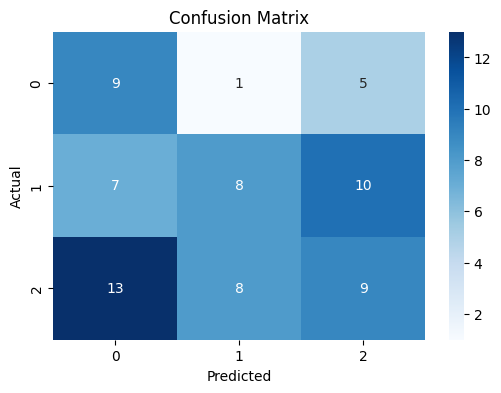

              precision    recall  f1-score   support

        High       0.31      0.60      0.41        15
         Low       0.47      0.32      0.38        25
      Medium       0.38      0.30      0.33        30

    accuracy                           0.37        70
   macro avg       0.39      0.41      0.37        70
weighted avg       0.40      0.37      0.37        70



In [52]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, final_pred))

In [53]:
print("Train Accuracy:", final_model.score(X_train_scaled, y_train))
print("Test Accuracy:", final_model.score(X_test_scaled, y_test))

Train Accuracy: 0.42857142857142855
Test Accuracy: 0.37142857142857144


In [54]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)

print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Train Accuracy: 0.7464285714285714
Test Accuracy: 0.37142857142857144


Random Forest has higher model capacity and tends to overfit small datasets. The significant train-test gap indicates overfitting, while Logistic Regression shows more stable but lower performance, suggesting weak predictive signal in features.

In [55]:
df["academic_risk"].value_counts()

academic_risk
Medium    152
Low       125
High       73
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

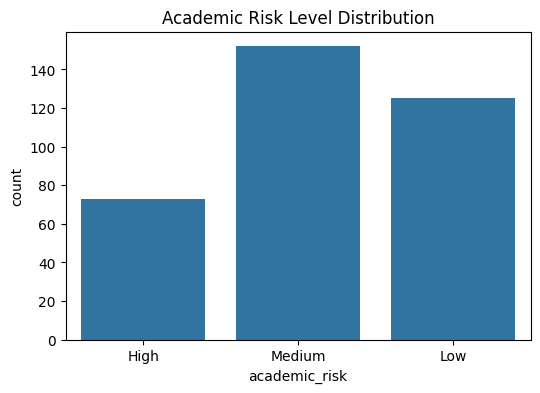

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="academic_risk", data=df)
plt.title("Academic Risk Level Distribution")
plt.show